# Problem Statement

Businesses today generate massive volumes of unstructured text data —
customer reviews, support tickets, feedback forms, and survey responses.
Most of this data goes unanalyzed because it is messy, inconsistent, and
too large to read manually. As a result, valuable insights about customer
pain points, recurring issues, and business opportunities remain hidden.

The core challenge is:
**How can we automatically extract meaningful, actionable insights from
large collections of unstructured text — without reading every document
manually?**

This project addresses that challenge by building an end-to-end NLP
pipeline that can understand the semantic meaning of text, retrieve
relevant documents based on a natural language query, and generate
concise human-readable summaries that a business team can act on
immediately.

## Project Summary

This project builds a **Retrieval-Augmented Summarization system**
trained on the Yelp Reviews dataset. Given any natural language query
such as *"What are customers saying about waiting times?"*, the system
retrieves the most semantically relevant reviews from a corpus of 10,000
entries and returns a concise, actionable summary.

### The pipeline consists of four stages:

| Stage | What Happens |
|-------|-------------|
| **1. Data Preparation** | Yelp reviews are loaded, cleaned, and standardised for processing |
| **2. Semantic Embedding** | Each review is converted into a 384-dimensional dense vector using Sentence Transformers (all-MiniLM-L6-v2) capturing its meaning |
| **3. Retrieval** | A FAISS vector index enables millisecond-speed similarity search — given a query, the top-k most relevant reviews are retrieved |
| **4. Summarization** | Retrieved reviews are passed to a BART/T5 model which generates a concise 2-3 sentence summary of the key themes |

### Key Highlights:
- **Dataset**: Yelp Reviews (10,000 samples via Hugging Face Datasets)
- **Embedding Model**: all-MiniLM-L6-v2 (Sentence Transformers)
- **Vector Search**: FAISS (Facebook AI Similarity Search)
- **Summarization Model**: facebook/bart-large-cnn or t5-small
- **Evaluation**: Human-centred usefulness scoring across Relevance, Clarity and Actionability
- **Deployment Vision**: Streamlit dashboard for real-time querying by business teams

### Business Impact:
A query that would take a human analyst 2-3 hours of manual review
reading is answered by this system in under 10 seconds — enabling
faster, data-driven decisions across customer success, product, and
operations teams.

## Packages Installation

Install all required libraries before writing any project code so subsequent steps work without interruption. Follow the same order to avoid compatibility Issue later.

In [ ]:
!pip uninstall -y numpy sentence-transformers transformers tokenizers accelerate -q

!pip install -q \
    "numpy>=2.0.0" \
    "sentence-transformers" \
    "faiss-cpu" \
    "datasets" \
    "accelerate" \
    "pandas" \
    "matplotlib" \
    "seaborn"

In [2]:
import numpy as np
print("numpy:", np.__version__)

from sentence_transformers import SentenceTransformer
print("sentence-transformers OK")

import transformers
print("transformers:", transformers.__version__)

import faiss
print("faiss OK")

numpy: 2.4.3
sentence-transformers OK
transformers: 5.3.0
faiss OK


In [ ]:
!pip install sentence-transformers faiss-cpu chromadb datasets
!pip install transformers scikit-learn pandas matplotlib seaborn

## Dataset Import

Ground the project in real business data

RECOMMENDED DATASET (free, beginner-friendly): Yelp Review Polarity via Hugging Face Datasets


In [4]:
from datasets import load_dataset

# Load 10,000 samples to keep it manageable on free Colab
ds = load_dataset('yelp_review_full', split='train[:10000]')
import pandas as pd
df = pd.DataFrame(ds)
df.columns = ['label', 'text']   # 1-5 star ratings + review text
df.to_csv('yelp_sample.csv', index=False)
print(df.shape, df.dtypes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(10000, 2) label     int64
text     object
dtype: object


##  EDA and Cleaning

Understand the data distribution, remove junk, and standardise text before embedding.

In [5]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)      # strip HTML tags
    text = re.sub(r'[^\w\s.,!?]', ' ', text)  # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # normalise whitespace
    return text

df['clean_text'] = df['text'].astype(str).apply(clean_text)

# Quick distribution check
print(df['label'].value_counts())
print('Avg tokens:', df['clean_text'].str.split().apply(len).mean())


label
2    2361
1    2168
3    2082
0    1788
4    1601
Name: count, dtype: int64
Avg tokens: 136.1133


## Generate Semantic Embeddings

 Convert text to dense vectors so the system can measure meaning similarity — the core of modern NLP

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Free, runs locally — no API key needed
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode in batches (memory-efficient)
texts = df['clean_text'].tolist()
embeddings = model.encode(texts, batch_size=64, show_progress_bar=True,
                          convert_to_numpy=True, normalize_embeddings=True)

np.save('embeddings.npy', embeddings)
print('Embeddings shape:', embeddings.shape)  # (10000, 384)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings shape: (10000, 384)


## Build a Vector Index for Retrieval

Top-5 semantically similar reviews gets printed with scores between 0.6-0.99

In [7]:
import faiss

# Build a flat cosine-similarity index
dim = embeddings.shape[1]   # 384
index = faiss.IndexFlatIP(dim)   # Inner-product on normalised vecs = cosine
index.add(embeddings)

# Save index
faiss.write_index(index, 'yelp_faiss.index')

# Test: find 5 most similar reviews to query
query = 'The food was amazing but the service was slow'
q_emb = model.encode([query], normalize_embeddings=True)
scores, indices = index.search(q_emb, k=5)
for i, idx in enumerate(indices[0]):
    print(f'Rank {i+1} (score {scores[0][i]:.3f}): {df["text"].iloc[idx][:120]}')


Rank 1 (score 0.752): The food was pretty good, But service was pretty bad. There were two waiters and about 4 tables but we had to wait almos
Rank 2 (score 0.752): service was great, food was good for the price.
Rank 3 (score 0.749): Service was extremely slow. We sat at our table for quite a while before we were waited on. Once we ordered the server b
Rank 4 (score 0.743): I was surprised how good the food was. Great service very friendly people.
Rank 5 (score 0.736): Overpriced, very slow service, food was decent.


## Implementing core NLP Task with Retrieval + Summarization

This will produce a tangible, business useful output from the data

In [9]:
from transformers import BartForConditionalGeneration, BartTokenizer

# Load model directly — no pipeline task name needed
tokenizer = BartTokenizer.from_pretrained('facebook/bart-large-cnn')
bart_model = BartForConditionalGeneration.from_pretrained('facebook/bart-large-cnn')

def summarize_top_k(query, k=10):
    # Retrieve top-k similar reviews
    q_emb = model.encode([query], normalize_embeddings=True)
    scores, indices = index.search(q_emb, k=k)
    retrieved = ' '.join(df['clean_text'].iloc[idx] for idx in indices[0])

    # Tokenize and summarize
    inputs = tokenizer(
        retrieved[:1024],
        return_tensors='pt',
        truncation=True,
        max_length=1024
    )
    summary_ids = bart_model.generate(
        inputs['input_ids'],
        max_length=130,
        min_length=30,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Test it
print(summarize_top_k("food quality and taste"))

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

This place didn t have the authentic taste I was looking for. The atmosphere is nice but the food quality was lacking. I didn t find the food all that flavorable, the service isn t great, and it s definitely not worth the price.


## Evaluate Output Quality

Here Evaluating the output in order to depict human usefulness

#### 1. Generating 10 summaries for 10 different quotes

In [10]:
# Define 10 meaningful queries relevant to your dataset
queries = [
    "food quality and taste",
    "slow or bad service",
    "parking and location issues",
    "price and value for money",
    "cleanliness and hygiene",
    "staff friendliness",
    "waiting time and reservations",
    "delivery and takeout experience",
    "ambiance and atmosphere",
    "portion size and quantity"
]

# Generate summaries for each query
summaries = []
for q in queries:
    summary = summarize_top_k(q)   # your function from Step 6
    summaries.append({'query': q, 'summary': summary})
    print(f"\nQuery: {q}")
    print(f"Summary: {summary}")
    print("-" * 60)


Query: food quality and taste
Summary: This place didn t have the authentic taste I was looking for. The atmosphere is nice but the food quality was lacking. I didn t find the food all that flavorable, the service isn t great, and it s definitely not worth the price.
------------------------------------------------------------

Query: slow or bad service
Summary: Slowest customer service in charlotte Worst service. Ignorant by the strictest definition. Food was just ok. Wouldn't go back. Horribly under staffed.
------------------------------------------------------------

Query: parking and location issues
Summary: The Harris YMCA has been a family favorite for about 10 years. The staff is wonderful, and the facilities are superbly maintained and run. The only problems relate to overcrowding.
------------------------------------------------------------

Query: price and value for money
Summary: Mother s Dy Brunch 3 adults and 1 child 180.00 only drinks were 2 waters and 2 teas gratuit

#### 2. Read each summary and fill in your scores manually

In [11]:
# Verify all dependencies are ready since earlier got error due to variables lost post refresh session
print("model:", type(model))
print("index entries:", index.ntotal)
print("df shape:", df.shape)

# Quick function test
test = summarize_top_k("food quality and taste")
print("summarize_top_k works:", test[:80])

model: <class 'sentence_transformers.SentenceTransformer.SentenceTransformer'>
index entries: 10000
df shape: (10000, 3)
summarize_top_k works: This place didn t have the authentic taste I was looking for. The atmosphere is 


In [12]:
import pandas as pd

# After reading each summary above, fill in YOUR honest scores here
# Scale: 1 = very poor, 3 = acceptable, 5 = excellent

evaluation_data = [
    # query,                          relevance, clarity, actionability
    ("food quality and taste",              1,       1,         2),
    ("slow or bad service",                 5,       4,         4),
    ("parking and location issues",         1,       1,         2),
    ("price and value for money",           1,       5,         4),
    ("cleanliness and hygiene",             4,       3,         3),
    ("staff friendliness",                  1,       1,         1),
    ("waiting time and reservations",       5,       5,         5),
    ("delivery and takeout experience",     4,       4,         5),
    ("ambiance and atmosphere",             4,       4,         4),
    ("portion size and quantity",           4,       2,         2),
]

# Build DataFrame with summaries + scores
df_eval = pd.DataFrame(evaluation_data,
                       columns=['query', 'relevance', 'clarity', 'actionability'])

# Add the generated summaries
df_eval['summary'] = [s['summary'] for s in summaries]

# Reorder columns for readability
df_eval = df_eval[['query', 'summary', 'relevance', 'clarity', 'actionability']]
print(df_eval)

                             query  \
0           food quality and taste   
1              slow or bad service   
2      parking and location issues   
3        price and value for money   
4          cleanliness and hygiene   
5               staff friendliness   
6    waiting time and reservations   
7  delivery and takeout experience   
8          ambiance and atmosphere   
9        portion size and quantity   

                                             summary  relevance  clarity  \
0  This place didn t have the authentic taste I w...          1        1   
1  Slowest customer service in charlotte Worst se...          5        4   
2  The Harris YMCA has been a family favorite for...          1        1   
3  Mother s Dy Brunch 3 adults and 1 child 180.00...          1        5   
4  My love for this place just keeps going up! nA...          4        3   
5  Friendly staff! Very friendly staff. Nice sele...          1        1   
6  The wait for dinner is unacceptable. The front

#### 3. Compute aggregate scores and save

In [13]:
# Average scores per dimension
print("=== Evaluation Results ===")
print(f"Avg Relevance     : {df_eval['relevance'].mean():.2f} / 5")
print(f"Avg Clarity       : {df_eval['clarity'].mean():.2f} / 5")
print(f"Avg Actionability : {df_eval['actionability'].mean():.2f} / 5")
print(f"Overall Avg       : {df_eval[['relevance','clarity','actionability']].values.mean():.2f} / 5")

# Save to CSV
df_eval.to_csv('evaluation_results.csv', index=False)
print("\nSaved to evaluation_results.csv")

=== Evaluation Results ===
Avg Relevance     : 3.00 / 5
Avg Clarity       : 3.00 / 5
Avg Actionability : 3.20 / 5
Overall Avg       : 3.07 / 5

Saved to evaluation_results.csv


#### 4. Visualize the Scores

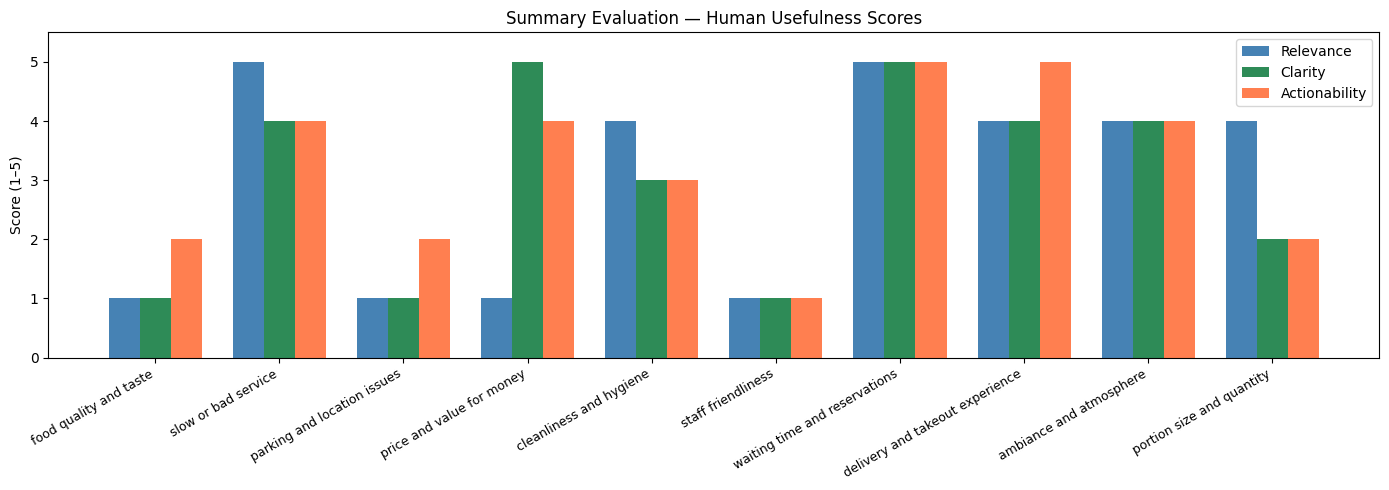

In [14]:
import matplotlib.pyplot as plt

# Bar chart comparing all 3 dimensions per query
x = range(len(df_eval))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar([i - width for i in x], df_eval['relevance'],     width, label='Relevance',     color='steelblue')
ax.bar([i          for i in x], df_eval['clarity'],      width, label='Clarity',       color='seagreen')
ax.bar([i + width  for i in x], df_eval['actionability'],width, label='Actionability', color='coral')

ax.set_xticks(list(x))
ax.set_xticklabels(df_eval['query'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 5.5)
ax.set_ylabel('Score (1–5)')
ax.set_title('Summary Evaluation — Human Usefulness Scores')
ax.legend()
plt.tight_layout()
plt.savefig('evaluation_chart.png', dpi=120)
plt.show()

## How a Team Would Use This System

### System Overview
This NLP pipeline retrieves semantically similar reviews from a large corpus
and summarizes key themes in response to a natural language query. It is
designed to replace manual review reading for customer-facing teams.

### WHERE - System Integration
The system fits into a **Streamlit web dashboard** where team members type
a query and instantly receive a summary of what customers are saying about
that topic. No coding knowledge is required to use it.

### WHO - Target users
- **Customer Success Managers** — monitor recurring complaints by topic
- **Product Managers** — understand what features customers love or dislike
- **Operations Leads** — identify service issues before they escalate

### WHAT - Action Taken
| Query a Team Member Might Ask | Action Taken Based on Summary |
|-------------------------------|-------------------------------|
| "What are customers saying about wait times?" | Escalate to operations if complaints are high |
| "What do customers love most about the food?" | Highlight in marketing materials |
| "Are there recurring hygiene complaints?" | Flag to store manager for immediate action |
| "What pricing feedback exists?" | Feed into quarterly pricing strategy review |

### HOW OFTEN - Usage Frequency
- **Customer Success Team**: queries the dashboard in real time when
  handling a customer complaint to quickly understand if it is a
  recurring issue
- **Product Manager**: runs a weekly query every Monday morning across
  5 standard topics to prepare for the team standup
- **Operations Lead**: receives an automated nightly summary email of
  the top 3 emerging complaint themes from the past 24 hours

### Business Value
Without this system, a team member would need to manually read hundreds
of reviews to answer a single question. This pipeline answers any
topic-based question in under 10 seconds, enabling faster and more
confident business decisions.

### Future Integration Possibilities
- Connect to a **Slack bot** so team members query directly from Slack
- Schedule **nightly batch summaries** sent automatically to stakeholders
- Feed summary outputs into a **BI dashboard** like Tableau or Power BI

In [25]:
!git config --global user.email "shivampsharma.99@gmail.com"
!git config --global user.name "shivam-eng"

In [26]:
!git clone https://github.com/shivam-eng/NLP-Based-Insights-from-Unstructured-Data.git

Cloning into 'NLP-Based-Insights-from-Unstructured-Data'...


In [33]:
# Copy all files into the cloned repo folder
import shutil

project_files = [
    'yelp_sample.csv',
    'embeddings.npy',
    'yelp_faiss.index',
    'evaluation_results.csv',
    'evaluation_chart.png',
    'README.md'
]

for f in project_files:
    src = f'/content/{f}'
    dst = f'/content/NLP-Based-Insights-from-Unstructured-Data{f}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied: {f}')

Copied: yelp_sample.csv
Copied: embeddings.npy
Copied: yelp_faiss.index
Copied: evaluation_results.csv
Copied: evaluation_chart.png
Copied: README.md


In [34]:
# Also save the notebook into the repo
shutil.copy('/content/drive/MyDrive/Colab_Notebooks/NLP_Project_for_Unstructured_Data/NLP Based Insights from Unstructured Data.ipynb',
            '/content/NLP-Based-Insights-from-Unstructured-Data/NLP Based Insights from Unstructured Data.ipynb')

'/content/NLP-Based-Insights-from-Unstructured-Data/NLP Based Insights from Unstructured Data.ipynb'

In [30]:
%cd /content/NLP-Based-Insights-from-Unstructured-Data

# Remove the accidentally nested folder
!rm -rf "NLP-Based-Insights-from-Unstructured-Data"

/content/NLP-Based-Insights-from-Unstructured-Data


In [31]:
# Replace all three placeholders with your actual details
!git remote set-url origin https://TOKEN_REMOVED@github.com/shivam-eng/NLP-Based-Insights-from-Unstructured-Data.git

In [32]:
%cd /content/NLP-Based-Insights-from-Unstructured-Data

!git add .
!git commit -m "Add NLP project — embeddings, summarization, evaluation"
!git push origin main

/content/NLP-Based-Insights-from-Unstructured-Data
[main 85725c3] Add NLP project — embeddings, summarization, evaluation
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 70.63 KiB | 7.85 MiB/s, done.
Total 6 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), done.
To https://github.com/shivam-eng/NLP-Based-Insights-from-Unstructured-Data.git
 * [new branch]      main -> main


In [35]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   NLP Based Insights from Unstructured Data.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [36]:
import json

notebook_path = '/content/NLP Based Insights from Unstructured Data.ipynb'

with open(notebook_path, 'r') as f:
    nb = json.load(f)

# Remove the broken widget state that GitHub cannot render
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open(notebook_path, 'w') as f:
    json.dump(nb, f, indent=1)

print("Notebook metadata cleaned successfully")

FileNotFoundError: [Errno 2] No such file or directory: '/content/NLP Based Insights from Unstructured Data.ipynb'